### Welcome to Indaba 2026 Skill Session: Fine-tuning Large Language Models for African Contexts!

To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance! This notebook will guide you through the exciting world of fine-tuning Large Language Models (LLMs), focusing on adapting them for the rich linguistic and cultural diversity of Africa.

<div class="align-center">
<img src="https://deeplearningindaba.com/wp-content/uploads/2025/08/indaba-logo.png" width="150" style="margin-right: 20px;">

#### Loading Our LLM: The Brain of the Operation

This is where we bring in our Large Language Model. We're using `FastModel.from_pretrained` which is like a VIP pass to quickly load powerful models. We'll specify things like `max_seq_length` (how much text it can 'remember' at once – imagine trying to fine-tune a friend's memory!), and whether we want to load it in a super-efficient 4-bit or 8-bit format. It's all about getting that big brain ready for its African context training!

# Indaba 2026 Skill Session: Fine-tuning LLMs for African Contexts

Welcome, future AI champions of Africa! In this hands-on skill session, we're diving deep into the art and science of fine-tuning Large Language Models (LLMs). Why? Because the digital future needs voices that resonate with the incredible diversity and richness of Africa. Generic models are like a suit off the rack – sometimes they fit, sometimes they don't quite capture your style. But a fine-tuned model? That's bespoke, tailored to understand and speak to the unique contexts of our continent.

This notebook is your workshop to master the skill of adapting powerful LLMs to African languages, cultures, and challenges. Think of it as teaching a global superstar model to sing local tunes, understand nuanced proverbs, and tell stories that truly hit home. By the end, you'll be equipped to build 'Sovereign Intelligence at African Scale'—creating AI that's not just powerful, but also deeply relevant and empowering for our communities.

Let's get cracking, shall we? Your journey to becoming an AI artisan for Africa begins now!

#### Getting the Tools Ready

This is where we install all the necessary Python libraries. Think of it as gathering your ingredients for a delicious meal – you can't cook without them! We'll be setting up `unsloth` and other essential packages. It's mostly automated, so you can sit back and relax. Just make sure your internet connection is ready for a little download dance!

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

#### Loading Our LLM: The Brain of the Operation

This is where we bring in our Large Language Model. We're using `FastModel.from_pretrained` which is like a VIP pass to quickly load powerful models. We'll specify things like `max_seq_length` (how much text it can 'remember' at once – imagine trying to fine-tune a friend's memory!), and whether we want to load it in a super-efficient 4-bit or 8-bit format. It's all about getting that big brain ready for its African context training!

In [ ]:
from unsloth import FastModel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
max_seq_length = 2048
fourbit_models = [
    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-27b-it-unsloth-bnb-4bit",

    # Other popular models!
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/Llama-3.3-70B",
    "unsloth/mistral-7b-instruct-v0.3",
    "unsloth/Phi-4",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-270m-it",
    max_seq_length = max_seq_length, # Choose any for long context!
    load_in_4bit = False,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # [NEW!] A bit more accurate, uses 2x memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    token = "YOUR_HF_TOKEN", # HF Token for gated models
)

We now add LoRA adapters so we only need to update a small amount of parameters!

To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>

<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

### Updates & Inspirations for African AI

This section highlights general progress and inspires further research in African AI, rather than specific product news. We aim to foster sovereign intelligence solutions at an African scale!

Innovations in AI are accelerating across the globe. Imagine what we can achieve when tailored for African contexts!

*   **Efficient LLM Training**: New methods enable faster LLM training with less VRAM, making advanced AI more accessible.
*   **Long-Context Models**: Breakthroughs in long-context capabilities mean models can process and understand more extensive African texts and dialogues.
*   **Ethical AI Development**: Continued focus on developing AI ethically, ensuring fairness and cultural relevance for all African communities.

Visit our resources for more information and to get involved in building AI for Africa.

### Installation

Before we dive into the fun stuff, we need to set up our environment. This is like gathering all your ingredients before you start cooking – you don't want to realize you're missing the salt halfway through! We'll be installing `unsloth` and other essential libraries. It's mostly automated, so just sit back and let the magic happen (or rather, let pip do its job).

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

### Model Loading with `FastModel` (Powered by optimized libraries)

`FastModel` provides an accelerated way to load and prepare models for training and inference, supporting a wide range of architectures, including both Vision and Text models. Think of it as your express train to model deployment, designed to save precious compute resources – because in AI, every byte and every second counts!

In [ ]:
from unsloth import FastModel
import torch
max_seq_length = 2048
fourbit_models = [
    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-1b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-4b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/gemma-3-27b-it-unsloth-bnb-4bit",

    # Other popular models!
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/Llama-3.3-70B",
    "unsloth/mistral-7b-instruct-v0.3",
    "unsloth/Phi-4",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-3-270m-it",
    max_seq_length = max_seq_length, # Choose any for long context!
    load_in_4bit = False,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # [NEW!] A bit more accurate, uses 2x memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    token = "YOUR_HF_TOKEN", # HF Token for gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/233 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

We now add LoRA adapters so we only need to update a small amount of parameters!

In [ ]:
model = FastModel.get_peft_model(
    model,
    r = 128, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 128,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

RuntimeError: Unsloth: You already added LoRA adapters to your model!

<a name="Data"></a>
### Data Prep

Think of this as teaching our model the local dialects and cultural nuances! We're going to feed it a rich dataset of conversations, but first, we need to make sure the data is dressed appropriately for our model's palate. No raw data here, please – we're going for a gourmet fine-tuning experience!

We now use the `Gemma-3` format for conversation style finetunes. We use the `CohereForAI/aya_dataset` and filter for Yoruba conversational data. Gemma-3 renders multi turn conversations like below:

```
<bos><start_of_turn>user
Hello!<end_of_turn>
<start_of_turn>model
Hey there!<end_of_turn>
```

In [ ]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "gemma3",
)

In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("CohereForAI/aya_dataset", split='train')

# Filter for Yoruba conversational data
african_chat = dataset.filter(lambda x: x['language'] == 'Yoruba')

# Preview a sample
print(f"Sample Prompt: {african_chat[0]['inputs']}")
print(f"Sample Response: {african_chat[0]['targets']}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/978k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/202362 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1750 [00:00<?, ? examples/s]

Filter:   0%|          | 0/202362 [00:00<?, ? examples/s]

Sample Prompt: Ijinigbe akẹkọọ Zamfara: Awọn obi fibinu ya bo ileewe, wọn ba dukia ijọba jẹ
Sample Response: Latari bawọn agbebọn ṣe ji awọn akẹkọọ-binrin to ju ọọdunrun lọ gbe nileewe ijọba Government Girls Secondary School, nipinlẹ Zamfara, awọn kan lara obi awọn awọn ọmọ naa ti lọọ ṣakọlu si ileewe ọhun, wọn si fibinu ba awọn dukia ijọba jẹ.

Gẹgẹ ba a ṣe gbọ, bojumọ ọjọ Ẹti, Furaidee, ṣe n mọ, lẹyin tiṣẹlẹ ijinigbe naa ti waye loru, awọn obi naa sare gba ileewe ọhun lọ, ni Jangebe, nijọba ibilẹ Talata-Mafara, onikaluku fẹẹ mọ boya ọmọ wọn ko si lara awọn ti wọn ko wọgbo ọhun.

Wọn ni iyalẹnu lo jẹ fawọn obi naa nigba ti wọn ri i pe awọn ọmọ to ṣeku ko fi ju aadọta (50) pere lọ, bẹẹ wọn lawọn ọmọ to n kawe nileewe ọhun le lẹgbẹta (600). Bakan naa ni wọn ni ọkan lara awọn tiṣa ileewe naa sọ pe awọn ọmọ ti wọn ji gbe naa ju ọọdunrun lọ daadaa, o ni wọn le lẹẹdẹgbẹta (500).

Ibinu iṣẹlẹ yii, ati ijakulẹ bijọba ko ṣe pese aabo to peye fawọn ọmọ wọn ni wọn lo fa a tawọn obi naa fi bẹrẹ s

Now that we've found our treasure trove of Yoruba conversations, we need to make sure it's in a format our model can easily understand and learn from. This next step is like putting all the raw ingredients into a blender to get that perfect smoothie texture! We're transforming the 'inputs' and 'targets' into a neat 'conversations' list, which is the model's preferred dinner plate for dialogue. No more scattered ingredients, just a perfectly prepared conversational feast!

In [ ]:
def convert_to_conversations(example):
    # This function converts 'inputs' and 'targets' into the 'conversations' format
    conversations = []
    if example['inputs']:
        conversations.append({"role": "user", "content": example["inputs"]})
    if example['targets']:
        conversations.append({"role": "assistant", "content": example["targets"]})
    return {"conversations": conversations}

# Apply the conversion to the filtered dataset
african_chat = african_chat.map(convert_to_conversations, remove_columns=['inputs', 'targets', 'language'])

Map:   0%|          | 0/11758 [00:00<?, ? examples/s]

Let's see how row 100 looks like!

In [ ]:
african_chat[100]

{'language_code': 'yor',
 'annotation_type': 'original-annotations',
 'user_id': '0960ac6d7eaa937cea44294c713dbe7a2efd78b63dcde4e632ded6ffa40a92b2',
 'conversations': [{'content': 'Ọwọ tẹ awọn gende meji to feẹ ji ọmọ gbe ni Supare Akoko',
   'role': 'user'},
  {'content': 'Diẹ lo ku ki wọn lu awọn gende meji kan pa lọsan-an ọjọ Aiku, Sannde, ọsẹ yii, niluu Supare Akoko, nijọba ibilẹ Guusu Iwọ-Oorun Akoko, lẹyin tọwọ tẹ wọn níbi ti wọn n gbiyanju ati ji ọmọ ọlọmọ gbe.\n\nALAROYE gbọ pe ṣe lawọn afurasi ajọmọgbe mejeeji dibọn bii awọn to maa n ṣa aloku irin lagboole kan ti wọn n pe ni Ajakaye Sadiku Muraina, ni Supare.\n\nObinrin kan lati agboole ọhun lo deede fariwo ta, to si ke sawọn eeyan nigba to ri awọn afurasi naa lasiko ti wọn ku giri wọle wọn, ti wọn si n gbiyanju ati ji ọmọ rẹ gbe sinu apo nla kan ti wọn fa lọwọ.\n\nKiakia lawọn araalu ti su bo wọn, ti wọn si n lu wọn lalubami ki wọn too tun fa wọn le ọlọpaa ilu Supare lọwọ.',
   'role': 'assistant'}]}

We now have to apply the chat template for `Gemma3` onto the conversations, and save it to `text`.

In [ ]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   # Ensure that `convos` is not empty after conversion
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False).removeprefix('<bos>') for convo in convos if convo]
   return { "text" : texts, }

# Filter out examples where conversations might be empty after conversion if necessary
african_chat = african_chat.filter(lambda x: len(x['conversations']) > 0 if 'conversations' in x else False)
african_chat = african_chat.map(formatting_prompts_func, batched = True)

# Rename the dataset variable to african_chat to be consistent with the data loading cell
dataset = african_chat

Filter:   0%|          | 0/11758 [00:00<?, ? examples/s]

Map:   0%|          | 0/11758 [00:00<?, ? examples/s]

Let's see how the chat template did!

In [ ]:
dataset[5]['text']

'<start_of_turn>user\nỌwọ tẹ awọn gende meji to feẹ ji ọmọ gbe ni Supare Akoko<end_of_turn>\n<start_of_turn>model\nDiẹ lo ku ki wọn lu awọn gende meji kan pa lọsan-an ọjọ Aiku, Sannde, ọsẹ yii, niluu Supare Akoko, nijọba ibilẹ Guusu Iwọ-Oorun Akoko, lẹyin tọwọ tẹ wọn níbi ti wọn n gbiyanju ati ji ọmọ ọlọmọ gbe.\n\nALAROYE gbọ pe ṣe lawọn afurasi ajọmọgbe mejeeji dibọn bii awọn to maa n ṣa aloku irin lagboole kan ti wọn n pe ni Ajakaye Sadiku Muraina, ni Supare.\n\nObinrin kan lati agboole ọhun lo deede fariwo ta, to si ke sawọn eeyan nigba to ri awọn afurasi naa lasiko ti wọn ku giri wọle wọn, ti wọn si n gbiyanju ati ji ọmọ rẹ gbe sinu apo nla kan ti wọn fa lọwọ.\n\nKiakia lawọn araalu ti su bo wọn, ti wọn si n lu wọn lalubami ki wọn too tun fa wọn le ọlọpaa ilu Supare lọwọ.<end_of_turn>\n'

<a name="Train"></a>
### Train the model
Now let's train our model. We do 100 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [ ]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = None, # Can set up evaluation!
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 1, # Use GA to mimic batch size!
        warmup_steps = 5,
        # num_train_epochs = 1, # Set this for 1 full training run.
        max_steps = 100,
        learning_rate = 5e-5, # Reduce to 2e-5 for long training runs
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use TrackIO/WandB etc
    ),
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/11758 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetunes!

In [ ]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part = "<start_of_turn>model\n",
)

Map (num_proc=6):   0%|          | 0/11758 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/11758 [00:00<?, ? examples/s]

Unsloth: Removed 1 out of 11758 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


Let's verify masking the instruction part is done! Let's print the 100th row again.

In [ ]:
tokenizer.decode(trainer.train_dataset[10]["input_ids"])

'<bos><start_of_turn>user\nWọn ti dana sun too geeti Lekki-Ikoyi<end_of_turn>\n<start_of_turn>model\nIroyin to tẹ ALAROYE lọwọ bayii ni pe wọn ti dana sun too geeti Ikoyi.\n\nKo ti i sẹni to mọ awọn to ṣiṣẹ naa, ṣugbọn awọn kan ni o ṣee ṣe ko jẹ awọn ọdọ ti inu n bi pelu bi awọn ṣọja ṣe yinbọn pa awọn kan ninu wọn lo ṣiṣẹ naa. Ṣugbọn a ko ti i le fidi eleyii mulẹ.<end_of_turn>\n'

Now let's print the masked out example - you should see only the answer is present:

In [ ]:
tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[100]["labels"]]).replace(tokenizer.pad_token, " ")

'                                      Eeyan meji mi-in ni arun Korona tun gbẹmin wọn mọjumọ ọjọ Aje, Mọnde, ọsẹ yii, bo ti ṣe tan ka ijọba ibilẹ mọkanla ninu mẹrindinlogun to wa nipinlẹ Kwara.\n\nLapapọ, awọn marundinlọgbọn ni wọn ti padanu ẹmi wọn lati igba ti arun naa ti wọ Kwara.\n\nAwọn marun-un mi-in tun lugbadi arun naa lọjọ Aiku, Sannde, ọsẹ yii, bẹẹ lawọn alaisan mẹjọ gba iyọnda lati gba ile wọn lọ.\n\nAtẹjade kan ti Alukoro igbimọ to n mojuto arun naa, Rafiu Ajakaye, gbe sita ṣalaye pe eeyan ọgọrun ati mọkanlelaaadọrin, 171, lo ṣi ni arun naa, wọn wa nibudo tijọba ya sọtọ fun itọju wọn.\n\nBakan naa, awọn ijọba ibilẹ mọkanla ti ajakalẹ arun naa ti tan de ni: Ilọrin South, Ilọrin West, Ilọrin East, Offa, Ifẹlodun, Asa, Ẹdu, Oke-Ẹrọ, Irẹpọdun, Moro ati Ọyun.<end_of_turn>\n'

In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
0.832 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 11,757 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 1 x 1) = 4
 "-____-"     Trainable parameters = 30,375,936 of 298,474,112 (10.18% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,5.231000
2,4.618700
3,4.170600
4,4.862600
5,5.121700
6,4.646300
7,5.084300
8,5.115200
9,5.167100
10,4.290000


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

513.2572 seconds used for training.
8.55 minutes used for training.
Peak reserved memory = 9.162 GB.
Peak reserved memory for training = 8.33 GB.
Peak reserved memory % of max memory = 62.913 %.
Peak reserved memory for training % of max memory = 57.2 %.


In [ ]:
# Access the training log history
training_log = pd.DataFrame(trainer.state.log_history)

# Display the training log, focusing on loss
display(training_log[['loss', 'learning_rate', 'epoch', 'step']].dropna(how='all'))

,loss,learning_rate,epoch,step
0,5.2310,0.000000e+00,0.000340,1
1,4.6187,1.000000e-05,0.000680,2
2,4.1706,2.000000e-05,0.001020,3
3,4.8626,3.000000e-05,0.001361,4
4,5.1217,4.000000e-05,0.001701,5
...,...,...,...,...
96,5.0481,2.105263e-06,0.032993,97
97,4.9465,1.578947e-06,0.033333,98
98,5.3541,1.052632e-06,0.033673,99
99,5.2767,5.263158e-07,0.034014,100


<a name="Inference"></a>
### Inference
Let's run the model via Unsloth native inference! According to the `Gemma-3` team, the recommended settings for inference are `temperature = 1.0, top_p = 0.95, top_k = 64`

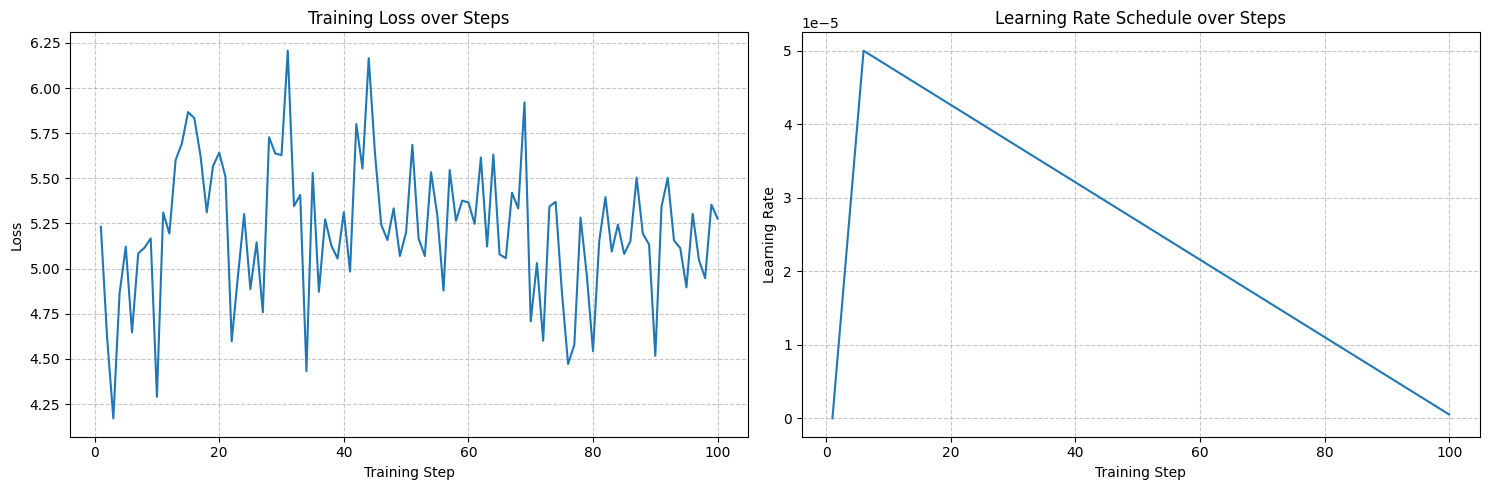

In [ ]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plotting Training Loss
sns.lineplot(x='step', y='loss', data=training_log.dropna(subset=['loss']), ax=axes[0])
axes[0].set_title('Training Loss over Steps')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plotting Learning Rate
sns.lineplot(x='step', y='learning_rate', data=training_log.dropna(subset=['learning_rate']), ax=axes[1])
axes[1].set_title('Learning Rate Schedule over Steps')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Learning Rate')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
messages = [
    {'role': 'system','content':dataset['conversations'][10][0]['content']},
    {"role" : 'user', 'content' : dataset['conversations'][10][1]['content']}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
).removeprefix('<bos>')

from transformers import TextStreamer
_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 125,
    temperature = 1, top_p = 0.95, top_k = 64,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
)

Ekure una awọn rẹ lati ninu awọn kan ni pe ba to gula gula n natemo ni ko wọn ko ati sẹni ko bẹgala n gbẹgala fun awọn ki lo ṣiṣẹ naa, yii. Awọn kẹ wọn tutu awọn lẹmi eri gula gula fun awọn bẹgala fun awọn kuti fi ko lẹẹ ọrọ ti fẹ ọdọ ọmọ ofui ọrọ ni awọn ara, ni o kofo si to rẹni lẹẹki pe ko pe sẹni


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("gemma_3_lora")  # Local saving
tokenizer.save_pretrained("gemma_3_lora")
# model.push_to_hub("your_name/gemma_3_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/gemma_3_lora", token = "YOUR_HF_TOKEN") # Online saving

('gemma-3/tokenizer_config.json',
 'gemma-3/special_tokens_map.json',
 'gemma-3/chat_template.jinja',
 'gemma-3/tokenizer.model',
 'gemma-3/added_tokens.json',
 'gemma-3/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "gemma_3_lora", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = 2048,
        load_in_4bit = False,
    )

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16 or `merged_4bit` for int4. We also allow `lora` adapters as a fallback. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
# Merge to 16bit
if False:
    model.save_pretrained_merged("gemma_3_finetune_16bit", tokenizer, save_method = "merged_16bit")
if False: # Pushing to HF Hub
    model.push_to_hub_merged("HF_USERNAME/gemma_3_finetune_16bit", tokenizer, save_method = "merged_16bit", token = "YOUR_HF_TOKEN")

# Merge to 4bit
if False:
    model.save_pretrained_merged("gemma_3_finetune_4bit", tokenizer, save_method = "merged_4bit",)
if False: # Pushing to HF Hub
    model.push_to_hub_merged("HF_USERNAME/gemma_3_finetune_4bit", tokenizer, save_method = "merged_4bit", token = "YOUR_HF_TOKEN")

# Just LoRA adapters
if False:
    model.save_pretrained("gemma_3_lora")
    tokenizer.save_pretrained("gemma_3_lora")
if False: # Pushing to HF Hub
    model.push_to_hub("HF_USERNAME/gemma_3_lora", token = "YOUR_HF_TOKEN")
    tokenizer.push_to_hub("HF_USERNAME/gemma_3_lora", token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now for all models! For now, you can convert easily to `Q8_0, F16 or BF16` precision. `Q4_K_M` for 4bit will come later!

In [ ]:
if False: # Change to True to save to GGUF
    model.save_pretrained_gguf(
        "gemma_3_finetune",
        tokenizer,
        quantization_method = "Q8_0", # For now only Q8_0, BF16, F16 supported
    )

Likewise, if you want to instead push to GGUF to your Hugging Face account, set `if False` to `if True` and add your Hugging Face token and upload location!

In [ ]:
if False: # Change to True to upload GGUF
    model.push_to_hub_gguf(
        "HF_ACCOUNT/gemma_3_finetune",
        tokenizer,
        quantization_method = "Q8_0", # Only Q8_0, BF16, F16 supported
        token = "YOUR_HF_TOKEN",
    )

And we're done!

Some other resources relevant to building African AI capabilities:
1.  **AI for African Languages**: Explore fine-tuning for low-resource African languages to preserve and promote linguistic diversity.
2.  **Data Sovereignty in AI**: Understand how fine-tuning local models can contribute to data sovereignty and culturally relevant AI solutions.
3.  **Community-driven AI Projects**: Get involved in initiatives that are building AI tools and applications specifically for African challenges and opportunities.

<div class="align-center">
  <a href="https://www.deeplearningindaba.com/"><img src="https://deeplearningindaba.com/wp-content/uploads/2025/08/indaba-logo.png" width="150" style="margin-right: 20px;"></a>
  
